In [4]:
## Exploratory Data Analysis

## Who defaults most?
## Which loans are riskiest?
## Which customer profiles are dangerous?
## What factors influence bad credit?

In [5]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns

In [6]:
df = pd.read_csv(r"C:\Users\User\Documents\SQL\Credit Risk Analysis Project\Raw Data\cleaned_credit_data.xls")

In [7]:
df

,status_account,loan_duration_months,credit_history,purpose,loan_amount,status_savings,years_employment,payment_to_income_ratio,status_and_sex,secondary_obligor,...,job,n_guarantors,telephone,is_foreign_worker,target,target_binary,age_group,loan_size,employment_risk,high_loan_flag
0,< 0 DM,6,critical account/ other credits existing (not ...,radio/television,1169,unknown/ no savings account,>= 7 years,4,male : single,none,...,skilled employee/ official,1,"yes, registered under the customers name",yes,good,0,50+,Small,Stable,0
1,0 to < 200 DM,48,existing credits paid back duly till now,radio/television,5951,< 100 DM,1 to < 4 years,2,female : divorced/separated/married,none,...,skilled employee/ official,1,none,yes,bad,1,18-25,Large,Stable,1
2,no checking account,12,critical account/ other credits existing (not ...,education,2096,< 100 DM,4 to < 7 years,2,male : single,none,...,unskilled - resident,2,none,yes,good,0,36-50,Medium,Stable,0
3,< 0 DM,42,existing credits paid back duly till now,furniture/equipment,7882,< 100 DM,4 to < 7 years,2,male : single,guarantor,...,skilled employee/ official,2,none,yes,good,0,36-50,Large,Stable,1
4,< 0 DM,24,delay in paying off in the past,car (new),4870,< 100 DM,1 to < 4 years,3,male : single,none,...,skilled employee/ official,2,none,yes,bad,1,50+,Large,Stable,1
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
995,no checking account,12,existing credits paid back duly till now,furniture/equipment,1736,< 100 DM,4 to < 7 years,3,female : divorced/separated/married,none,...,unskilled - resident,1,none,yes,good,0,26-35,Medium,Stable,0
996,< 0 DM,30,existing credits paid back duly till now,car (used),3857,< 100 DM,1 to < 4 years,4,male : divorced/separated,none,...,management/ self-employed/highly qualified emp...,1,"yes, registered under the customers name",yes,good,0,36-50,Large,Stable,1
997,no checking account,12,existing credits paid back duly till now,radio/television,804,< 100 DM,>= 7 years,4,male : single,none,...,skilled employee/ official,1,none,yes,good,0,36-50,Small,Stable,0
998,< 0 DM,45,existing credits paid back duly till now,radio/television,1845,< 100 DM,1 to < 4 years,4,male : single,none,...,skilled employee/ official,1,"yes, registered under the customers name",yes,bad,1,18-25,Medium,Stable,0


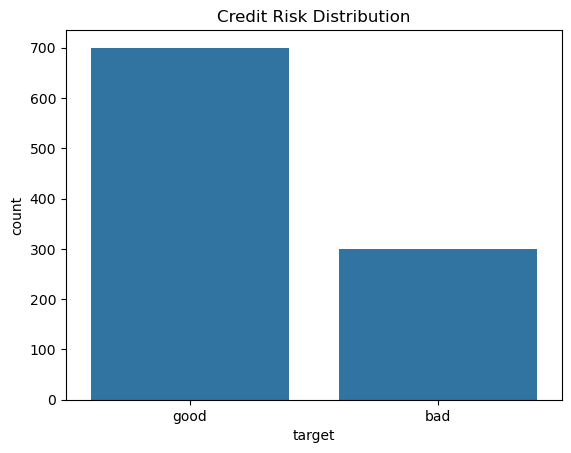

In [8]:
## Overall Default Distribution

sns.countplot(data=df, x='target')
plt.title('Credit Risk Distribution')
plt.show()

In [9]:
## Most customers are classified as good credit risks, but a significant minority 
## fall into the bad-risk category, making risk detection essential for minimizing losses.

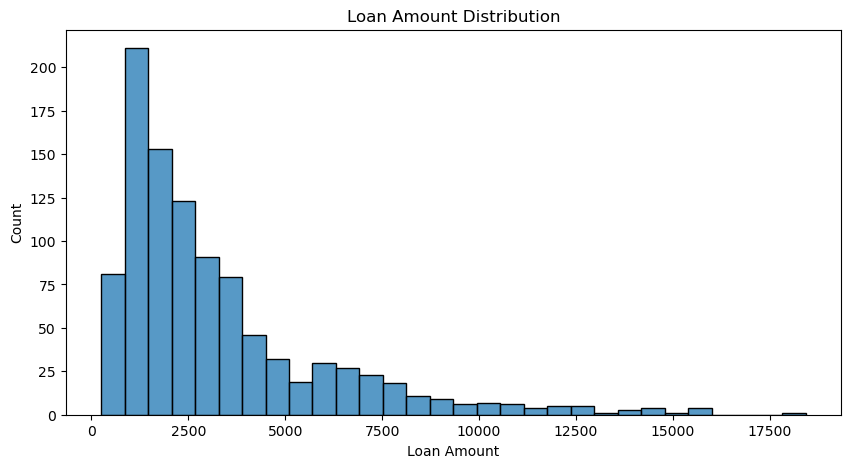

In [10]:
## Loan Amount Analysis

plt.figure(figsize=(10,5))

sns.histplot(df['loan_amount'], bins=30)

plt.title('Loan Amount Distribution')
plt.xlabel('Loan Amount')
plt.show()

In [11]:
## Most loans are small (around 2500$) with some few outliers (about 18000$)

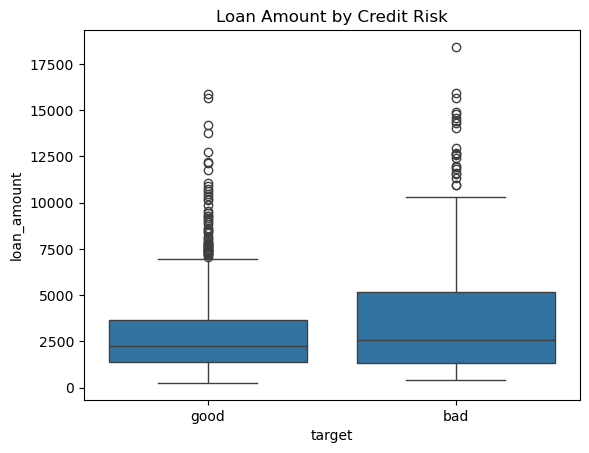

In [12]:
sns.boxplot(data=df, x='target', y='loan_amount')

plt.title('Loan Amount by Credit Risk')
plt.show()

In [13]:
## Customers classified as bad credit risks tend to request larger loan amounts on average.

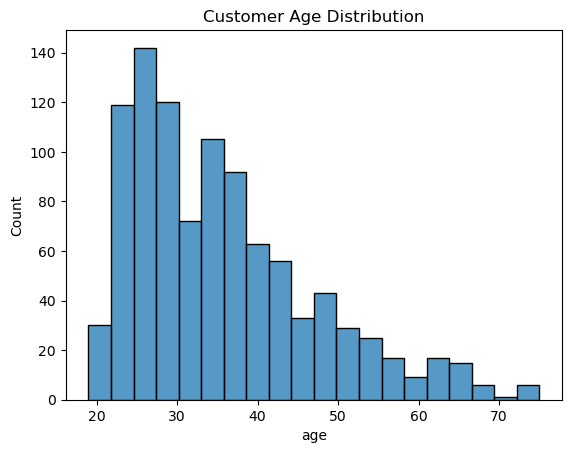

In [14]:
## Age Analysis

sns.histplot(df['age'], bins=20)

plt.title('Customer Age Distribution')
plt.show()

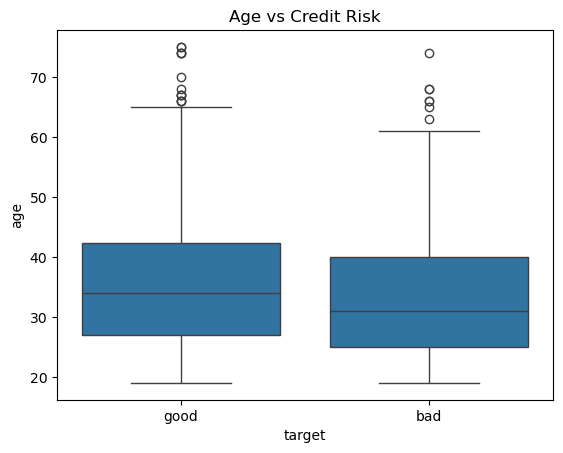

In [15]:
sns.boxplot(data=df, x='target', y='age')

plt.title('Age vs Credit Risk')
plt.show()

In [16]:
## Customers classified as bad credit risks tend to be younger on average.

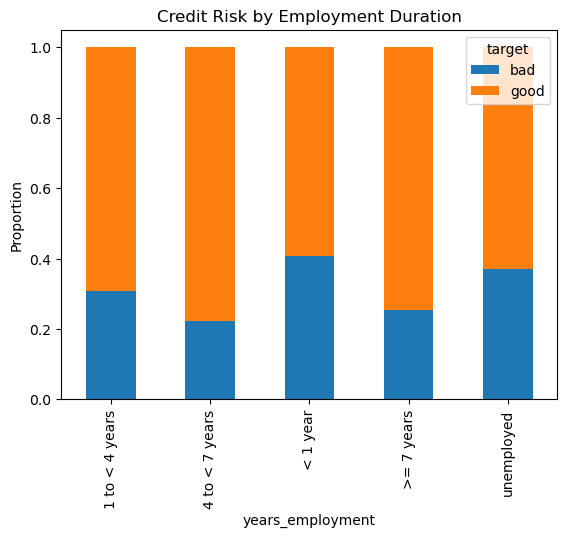

In [17]:
## Employment Stability Analysis

employment_risk = pd.crosstab(
    df['years_employment'],
    df['target'],
    normalize='index'
)

employment_risk.plot(kind='bar', stacked=True)

plt.title('Credit Risk by Employment Duration')
plt.ylabel('Proportion')
plt.show()

In [18]:
## Customers with shorter employment histories show higher proportions of bad credit outcomes, 
## suggesting employment stability is a strong indicator of repayment reliability.

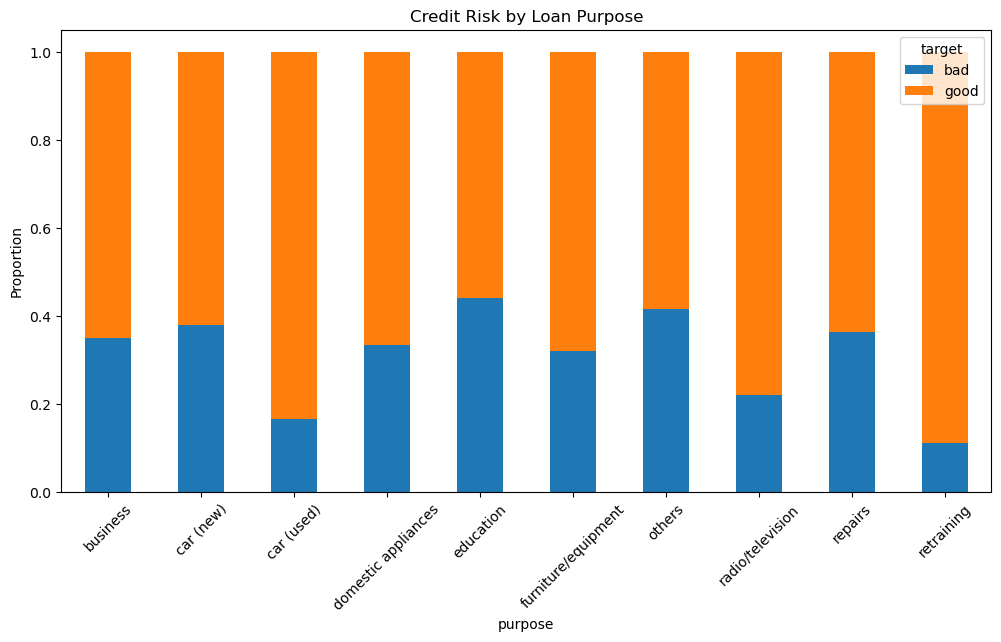

In [19]:
## Loan Purpose Risk Analysis

purpose_risk = pd.crosstab(
    df['purpose'],
    df['target'],
    normalize='index'
)

purpose_risk.plot(kind='bar', stacked=True, figsize=(12,6))

plt.title('Credit Risk by Loan Purpose')
plt.ylabel('Proportion')
plt.xticks(rotation=45)

plt.show()

In [20]:
## retraining, car(used), radio/television are the safest puposes
## education, others, cars(new), repairs are the riskiest purposes
## recommendation: the bank should tighten approvals for certain categories

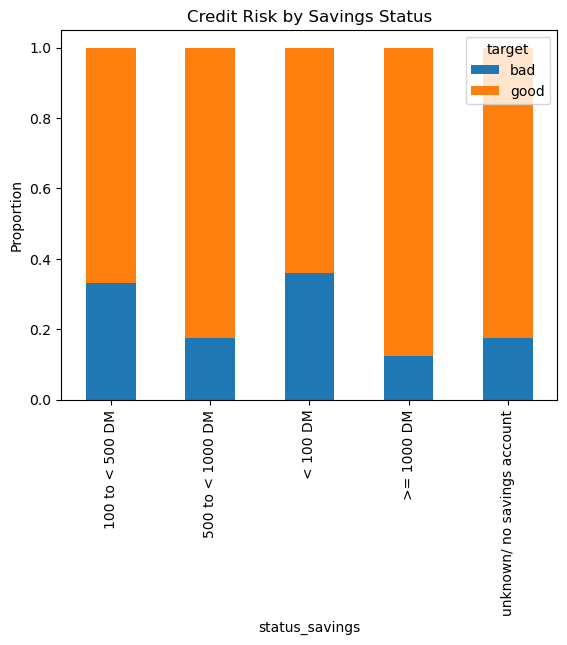

In [21]:
## Savings & Financial Stability

savings_risk = pd.crosstab(
    df['status_savings'],
    df['target'],
    normalize='index'
)

savings_risk.plot(kind='bar', stacked=True)

plt.title('Credit Risk by Savings Status')
plt.ylabel('Proportion')

plt.show()

In [22]:
## Customers with little or no savings tend to exhibit higher levels of credit risk.

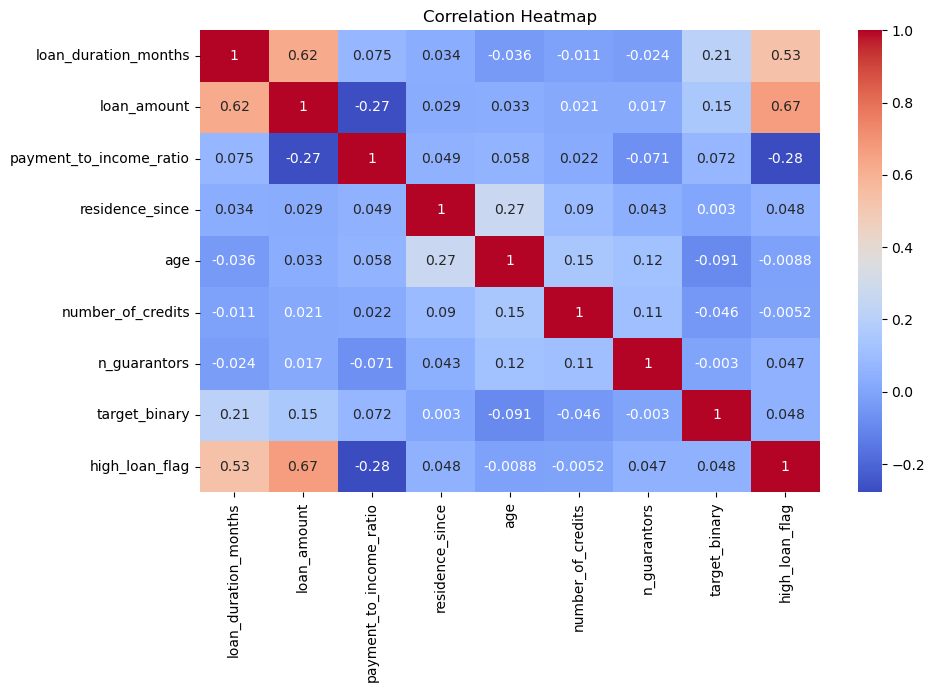

In [23]:
## Correlation Analysis

numeric_df = df.select_dtypes(include=np.number)

plt.figure(figsize=(10,6))

sns.heatmap(
    numeric_df.corr(),
    annot=True,
    cmap='coolwarm'
)

plt.title('Correlation Heatmap')

plt.show()

In [24]:
## The correlation analysis indicates that loan amount and loan duration exhibit a moderate positive relationship, 
## suggesting that larger loans are typically associated with longer repayment periods.
## Additionally, payment-to-income ratio shows signs of association with higher credit risk, 
## implying that customers with heavier financial burdens may be more likely to experience repayment difficulties. 
## Most variables demonstrate relatively weak individual correlations, 
## which is common in real-world financial datasets where credit risk is influenced by multiple interacting factors
## rather than a single dominant variable.

In [25]:
## Business insight:
## Customers categorized as bad credit risks tend to request larger loans, 
## suggesting the institution may benefit from stricter approval criteria 
## or enhanced verification processes for high-value lending applications.

In [26]:
## Creating Business KPI Table

total_customers = len(df)

bad_rate = (df['target'] == 'bad').mean() * 100

avg_loan = df['loan_amount'].mean()

avg_age = df['age'].mean()

print("Total Customers:", total_customers)
print("Bad Credit Rate:", round(bad_rate,2), "%")
print("Average Loan Amount:", round(avg_loan,2))
print("Average Age:", round(avg_age,2))

Total Customers: 1000
Bad Credit Rate: 30.0 %
Average Loan Amount: 3271.26
Average Age: 35.55


In [60]:
## Building a Risk Scoring System


## Define Risk Factors: 

## | Risk Factor                  | Why It Matters               |
## | ---------------------------- | ---------------------------- |
## | Long loan duration           | Higher repayment uncertainty |
## | Large loan amount            | Higher financial exposure    |
## | Poor credit history          | Strong default indicator     |
## | Low savings                  | Weak financial cushion       |
## | Short employment history     | Income instability           |
## | High payment-to-income ratio | Financial stress             |
## | Young age                    | Less financial maturity      |


In [73]:
## Creating Risk Points

df['risk_score'] = 0

In [74]:
## Credit History Weights

df.loc[
    df['credit_history'].isin([
        'no credits taken/ all credits paid back duly',
        'all credits at this bank paid back duly'
    ]),
    'risk_score'
] += 40

In [75]:
## Moderate Credit Risk

df.loc[
    df['credit_history'].isin([
        'delay in paying off in the past',
        'existing credits paid back duly till now'
    ]),
    'risk_score'
] += 20

In [76]:
## Savings Risk

df.loc[
    df['status_savings'] == '< 100 DM',
    'risk_score'
] += 25

In [77]:
## Employment Risk

df.loc[
    df['years_employment'] == '< 1 year',
    'risk_score'
] += 30

df.loc[
    df['years_employment'] == 'unemployed',
    'risk_score'
] += 25

In [78]:
## Loan Duration Risk

df.loc[df['loan_duration_months'] > 36, 'risk_score'] += 20

In [79]:
## Large Loan Risk

df.loc[
    df['loan_amount'] > df['loan_amount'].quantile(0.75),
    'risk_score'
] += 15

In [80]:
## Young Borrower Risk

df.loc[df['age'] < 25, 'risk_score'] += 10

In [81]:
## Risk Categories

def categorize_risk(score):
    if score <= 25:
        return 'Low Risk'
    elif score <= 60:
        return 'Medium Risk'
    else:
        return 'High Risk'

In [86]:
df['risk_level'] = df['risk_score'].apply(categorize_risk)
df

,status_account,loan_duration_months,credit_history,purpose,loan_amount,status_savings,years_employment,payment_to_income_ratio,status_and_sex,secondary_obligor,...,telephone,is_foreign_worker,target,target_binary,age_group,loan_size,employment_risk,high_loan_flag,risk_score,risk_level
0,< 0 DM,6,critical account/ other credits existing (not ...,radio/television,1169,unknown/ no savings account,>= 7 years,4,male : single,none,...,"yes, registered under the customers name",yes,good,0,50+,Small,Stable,0,0,Low Risk
1,0 to < 200 DM,48,existing credits paid back duly till now,radio/television,5951,< 100 DM,1 to < 4 years,2,female : divorced/separated/married,none,...,none,yes,bad,1,18-25,Large,Stable,1,90,High Risk
2,no checking account,12,critical account/ other credits existing (not ...,education,2096,< 100 DM,4 to < 7 years,2,male : single,none,...,none,yes,good,0,36-50,Medium,Stable,0,25,Low Risk
3,< 0 DM,42,existing credits paid back duly till now,furniture/equipment,7882,< 100 DM,4 to < 7 years,2,male : single,guarantor,...,none,yes,good,0,36-50,Large,Stable,1,80,High Risk
4,< 0 DM,24,delay in paying off in the past,car (new),4870,< 100 DM,1 to < 4 years,3,male : single,none,...,none,yes,bad,1,50+,Large,Stable,1,60,Medium Risk
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
995,no checking account,12,existing credits paid back duly till now,furniture/equipment,1736,< 100 DM,4 to < 7 years,3,female : divorced/separated/married,none,...,none,yes,good,0,26-35,Medium,Stable,0,45,Medium Risk
996,< 0 DM,30,existing credits paid back duly till now,car (used),3857,< 100 DM,1 to < 4 years,4,male : divorced/separated,none,...,"yes, registered under the customers name",yes,good,0,36-50,Large,Stable,1,45,Medium Risk
997,no checking account,12,existing credits paid back duly till now,radio/television,804,< 100 DM,>= 7 years,4,male : single,none,...,none,yes,good,0,36-50,Small,Stable,0,45,Medium Risk
998,< 0 DM,45,existing credits paid back duly till now,radio/television,1845,< 100 DM,1 to < 4 years,4,male : single,none,...,"yes, registered under the customers name",yes,bad,1,18-25,Medium,Stable,0,75,High Risk


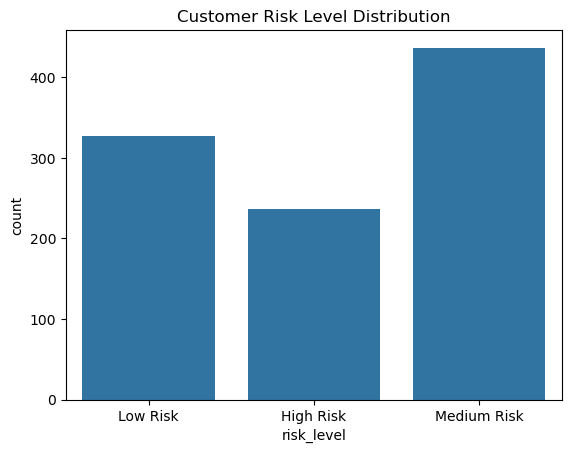

In [89]:
## Risk Tier Counts

sns.countplot(data=df, x='risk_level')

plt.title('Customer Risk Level Distribution')

plt.show()

In [90]:
## Compare Risk Level vs Actual Outcome

pd.crosstab(
    df['risk_level'],
    df['target'],
    normalize='index'
)

target,bad,good
risk_level,,
High Risk,0.538136,0.461864
Low Risk,0.137615,0.862385
Medium Risk,0.292906,0.707094


In [91]:
## Customers categorized as High Risk exhibit substantially higher proportions of bad credit outcomes, 
## indicating that the scoring framework successfully captures several key indicators associated with default behavior.

In [92]:
## Visualizing Risk Score

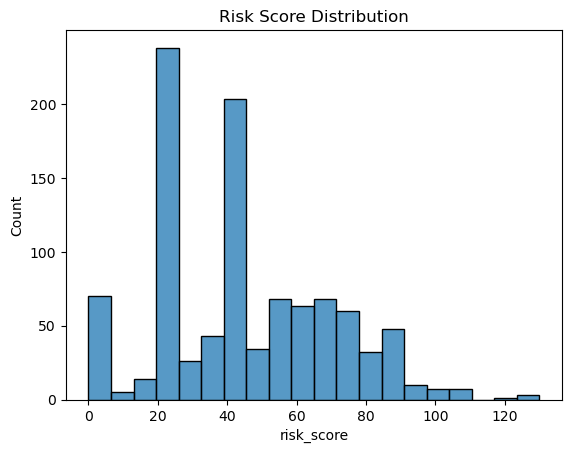

In [93]:
## Risk Score Distribution

sns.histplot(df['risk_score'], bins=20)

plt.title('Risk Score Distribution')

plt.show()

In [94]:
## Average Risk Score by Target

df.groupby('target')['risk_score'].mean()

target
bad     57.483333
good    39.200000
Name: risk_score, dtype: float64

In [95]:
## Borrowers classified as bad credit risks tend to have significantly higher average risk scores, 
## suggesting that the engineered scoring system aligns well with observed repayment outcomes.

In [96]:
df.to_csv('final_credit_risk_dataset.csv', index=False)